# Spatial Heatmap Comparison

2x2 heatmaps comparing Historical vs SSP scenarios for temperature and precipitation,
showing the spatial pattern across the park boundary.

Uses a Coiled cluster (4 workers) to fetch gridded snapshots in parallel.

In [1]:
import sys
import os
import coiled

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "lib"))

from andrewAdaptLibrary import (
    ParkCatalog,
    get_spatial_snapshot,
    plot_spatial_comparison,
)

NPS_SHP = os.path.join(
    PROJECT_ROOT,
    "USA_National_Park_Service_Lands_20170930_4993375350946852027",
    "USA_Federal_Lands.shp",
)
catalog = ParkCatalog(NPS_SHP)
print("Ready")

/opt/conda/envs/py-env/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: /workspaces/DSEBrandNew/USA_National_Park_Service_Lands_20170930_4993375350946852027/USA_Federal_Lands.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


Ready


## Load Park Boundaries

In [2]:
jt = catalog.get_boundary("Joshua Tree National Park")
mj = catalog.get_boundary("Mojave National Preserve")
print(f"Joshua Tree: {jt.total_bounds}")
print(f"Mojave: {mj.total_bounds}")

Joshua Tree: [-116.45805157   33.67019667 -115.26221427   34.12935132]
Mojave: [-116.16503909   34.71693524 -114.94916936   35.59077673]


## Start Coiled Cluster

In [3]:
cluster = coiled.Cluster(
    name="spatial-heatmap",
    region="us-west1",
    n_workers=4,
    worker_memory="8 GiB",
    spot_policy="spot_with_fallback",
    idle_timeout="15 minutes",
    package_sync=True,
)
client = cluster.get_client()
print(f"Workers: {len(client.scheduler_info()['workers'])}")

/tmp/ipykernel_3814/1957208973.py:1: FutureWarning: `package_sync` is a deprecated kwarg for `Cluster` and will be removed in a future release. To only sync certain packages, use `package_sync_only`, and to disable package sync, pass the `container` or `software` kwargs instead.
  cluster = coiled.Cluster(


Output()

╭──────────────────────────────── Package Info ────────────────────────────────╮
│                    ╷                                                         │
│   Package          │ Note                                                    │
│ ╶──────────────────┼───────────────────────────────────────────────────────╴ │
│   coiled_local_lib │ Source wheel built from /workspaces/DSEBrandNew/lib     │
│   climakitae       │ Wheel built from                                        │
│                    │ https://github.com/cal-adapt/climakitae/archive/refs/   │
│                    │ tags/1.4.0.zip                                          │
│                    ╵                                                         │
╰──────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────── Not Synced with Cluster ───────────────────────────╮
│             ╷                                                    ╷           │
│   Package   │ Error                                              │ Level     │
│ ╶───────────┼────────────────────────────────────────────────────┼─────────╴ │
│   shiboken6 │ cannot find shiboken6~=6.10.2 on pypi.org. If you  │ Warning   │
│             │ are using a custom PyPI URL, please see            │           │
│             │ https://docs.coiled.io/user_guide/software/packag… │           │
│             │ for more instructions.                             │           │
│             ╵                                                    ╵           │
╰──────────────────────────────────────────────────────────────────────────────╯

Output()

Workers: 0


## Joshua Tree: Max Temperature (2050–2069 vs Historical)

In [4]:
scenarios = ["Historical Climate", "SSP 2-4.5", "SSP 3-7.0", "SSP 5-8.5"]

jt_tmax = get_spatial_snapshot(
    variable="T_Max",
    scenarios=scenarios,
    boundary=jt,
    time_period=(2050, 2069),
    coiled_cluster=cluster,
)

for scen, da in jt_tmax.items():
    print(f"{scen}: shape={da.shape}, mean={float(da.mean()):.1f}°C")

Historical Climate: shape=(15, 39), mean=26.2°C
SSP 2-4.5: shape=(15, 39), mean=28.3°C
SSP 3-7.0: shape=(15, 39), mean=28.4°C
SSP 5-8.5: shape=(15, 39), mean=29.1°C


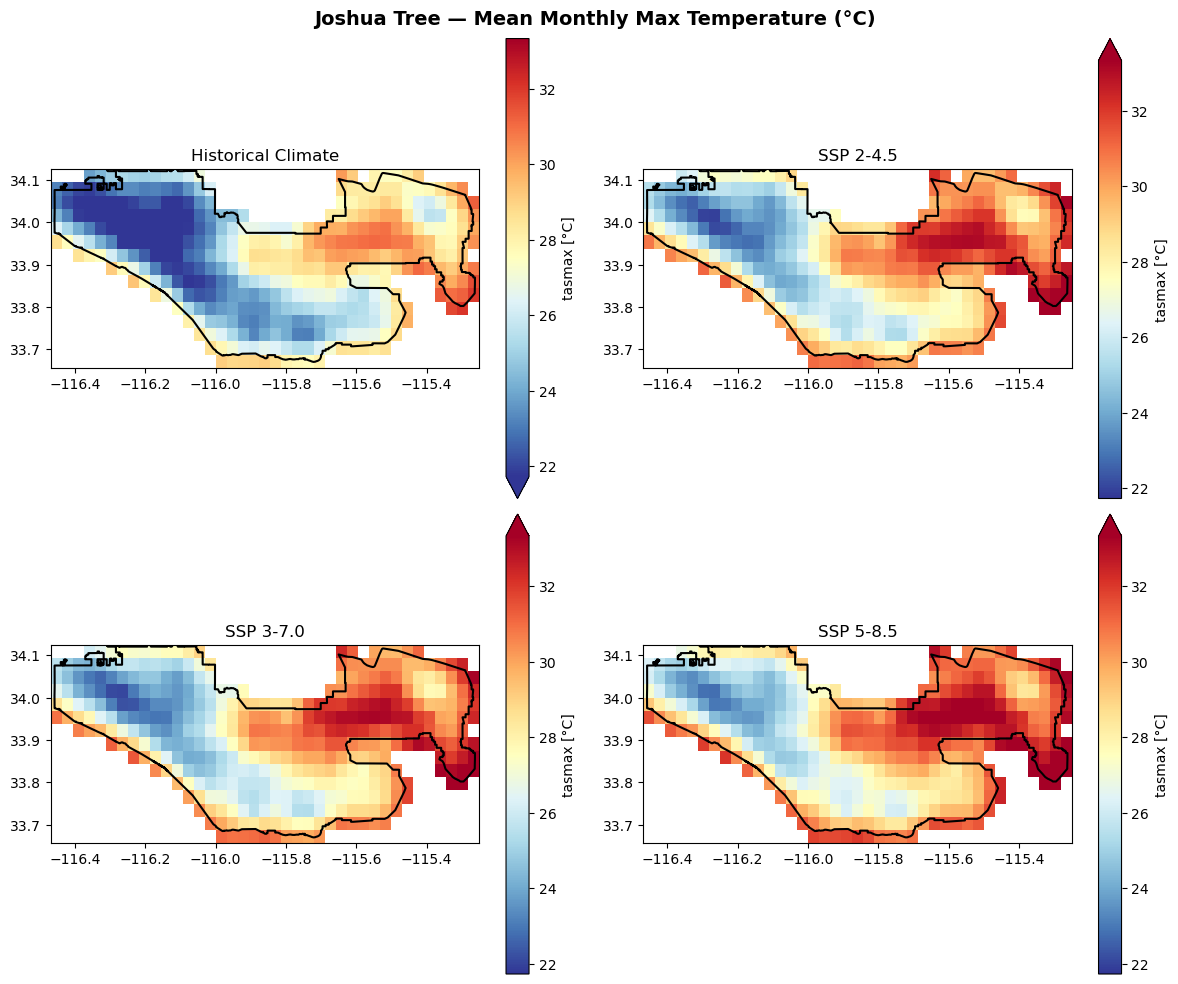

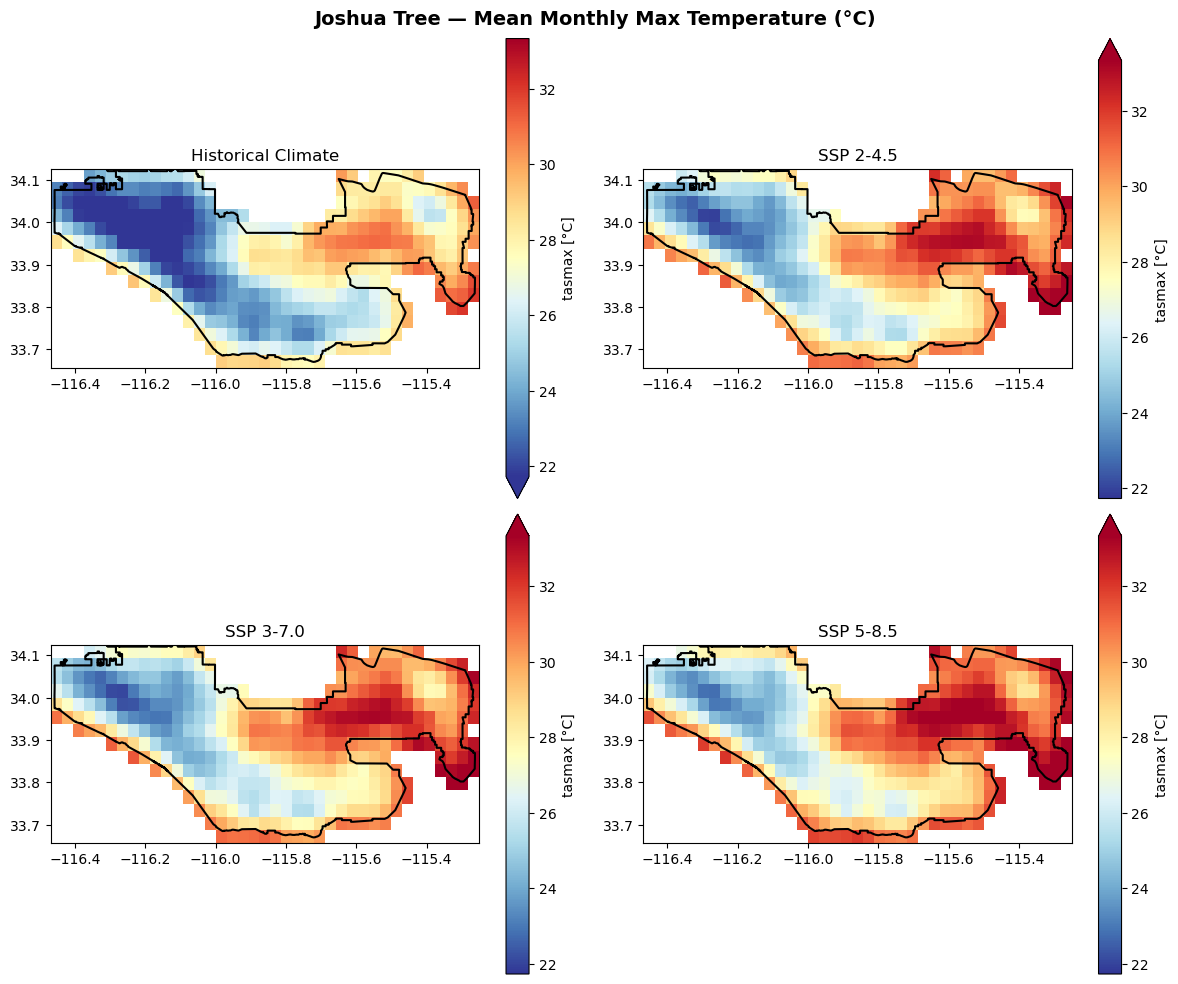

In [5]:
plot_spatial_comparison(
    jt_tmax,
    boundary=jt,
    title="Joshua Tree — Mean Monthly Max Temperature (°C)",
)

### Anomalies: Change from Historical Baseline

Subtract the Historical grid from each SSP to see where warming is strongest.

In [6]:
baseline = jt_tmax["Historical Climate"]

jt_tmax_anomalies = {
    f"{scen} minus Historical": da - baseline
    for scen, da in jt_tmax.items()
    if scen != "Historical Climate"
}

# Show the range
for scen, da in jt_tmax_anomalies.items():
    vals = da.values[~__import__('numpy').isnan(da.values)]
    print(f"{scen}: {vals.min():+.2f} to {vals.max():+.2f} °C")

SSP 2-4.5 minus Historical: +1.93 to +2.33 °C
SSP 3-7.0 minus Historical: +2.01 to +2.43 °C
SSP 5-8.5 minus Historical: +2.68 to +3.14 °C


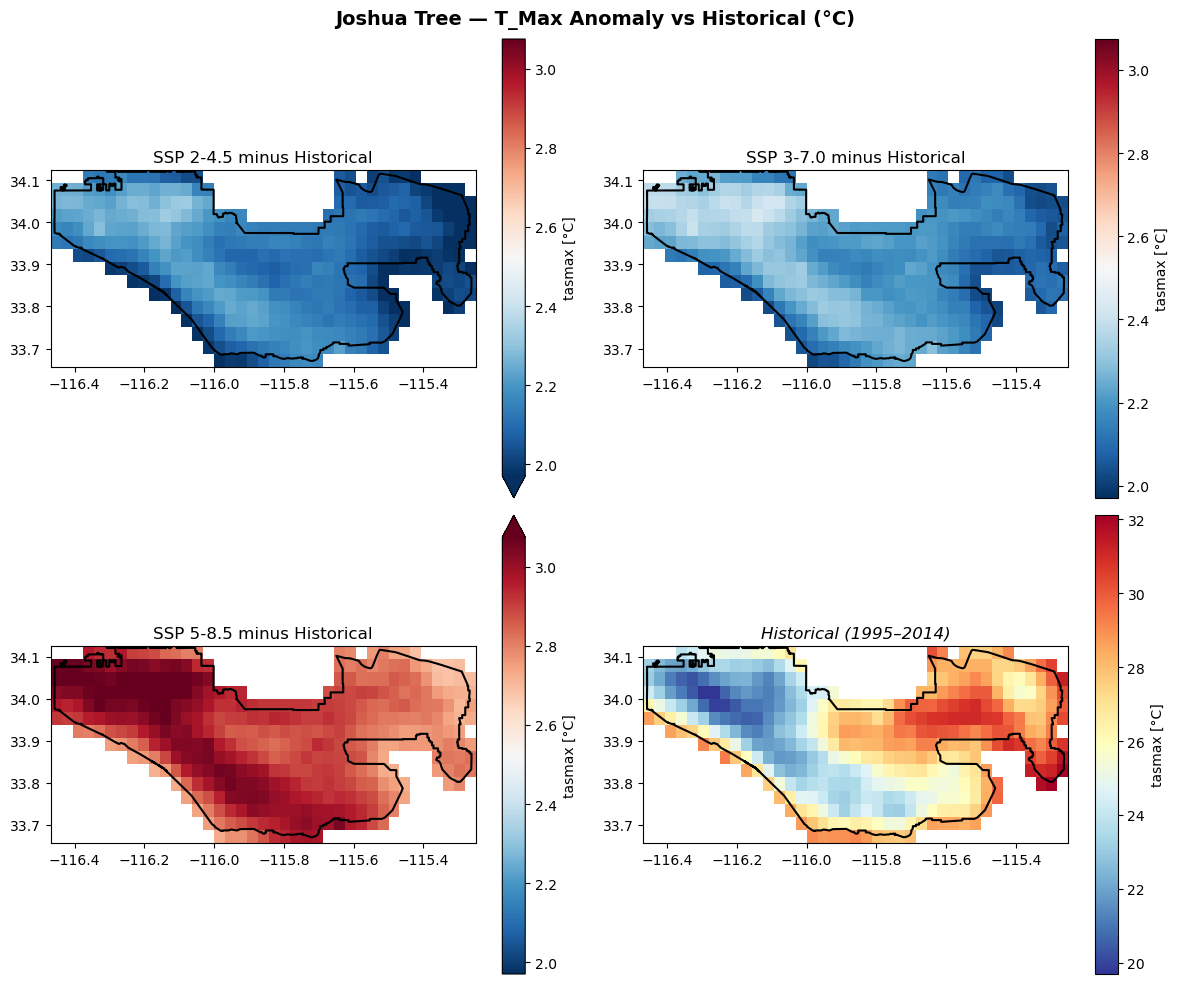

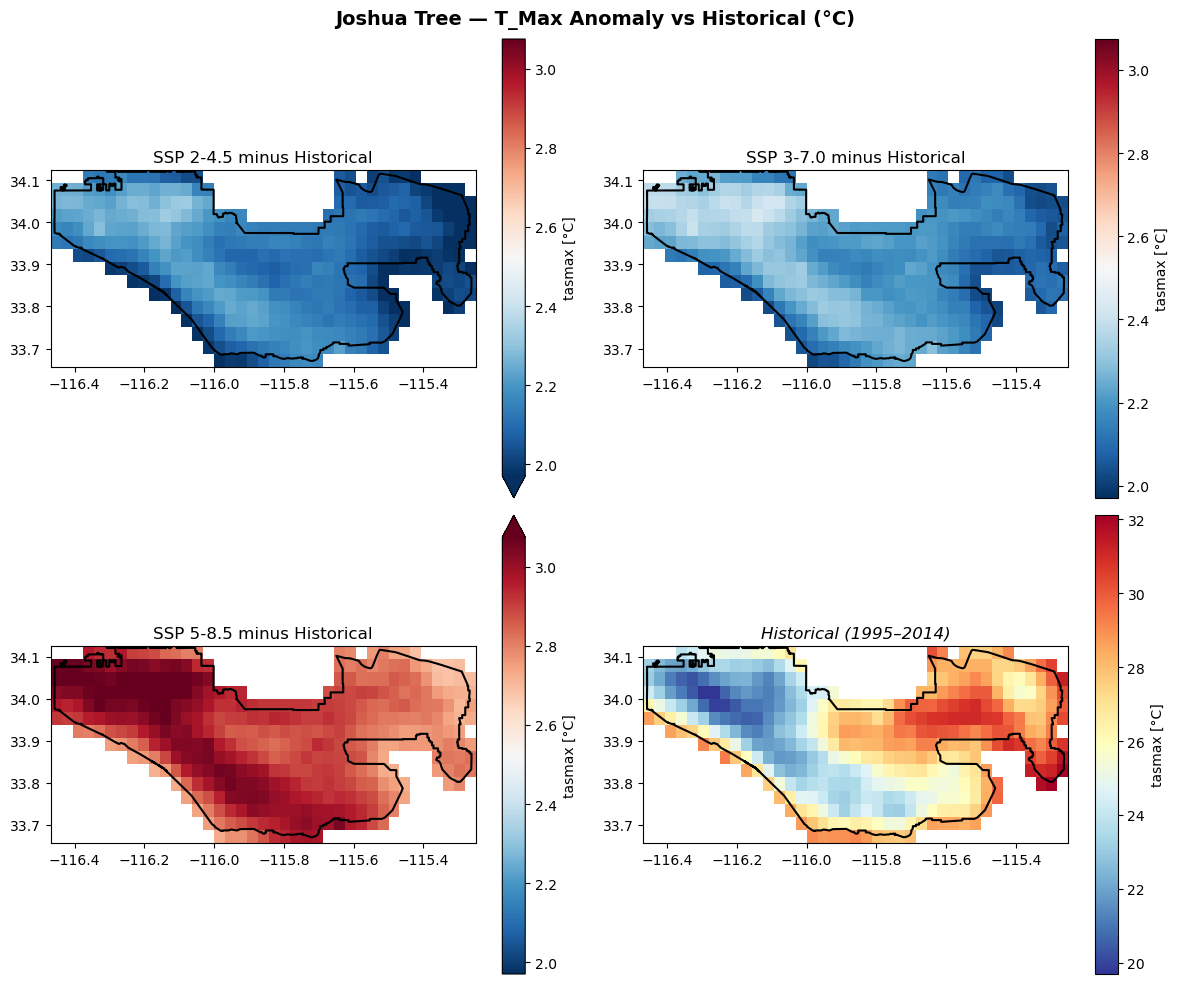

In [7]:
plot_spatial_comparison(
    jt_tmax_anomalies,
    boundary=jt,
    title="Joshua Tree — T_Max Anomaly vs Historical (°C)",
    cmap="RdBu_r",
    reference_panel=("Historical (1995–2014)", jt_tmax["Historical Climate"], "RdYlBu_r"),
)

## Mojave: Precipitation (2050–2069 vs Historical)

In [8]:
mj_precip = get_spatial_snapshot(
    variable="Precip",
    scenarios=scenarios,
    boundary=mj,
    time_period=(2050, 2069),
    coiled_cluster=cluster,
)

for scen, da in mj_precip.items():
    print(f"{scen}: shape={da.shape}, mean={float(da.mean()):.1f} mm/month")

Historical Climate: shape=(28, 39), mean=15.7 mm/month
SSP 2-4.5: shape=(28, 39), mean=15.3 mm/month
SSP 3-7.0: shape=(28, 39), mean=14.9 mm/month
SSP 5-8.5: shape=(28, 39), mean=16.6 mm/month


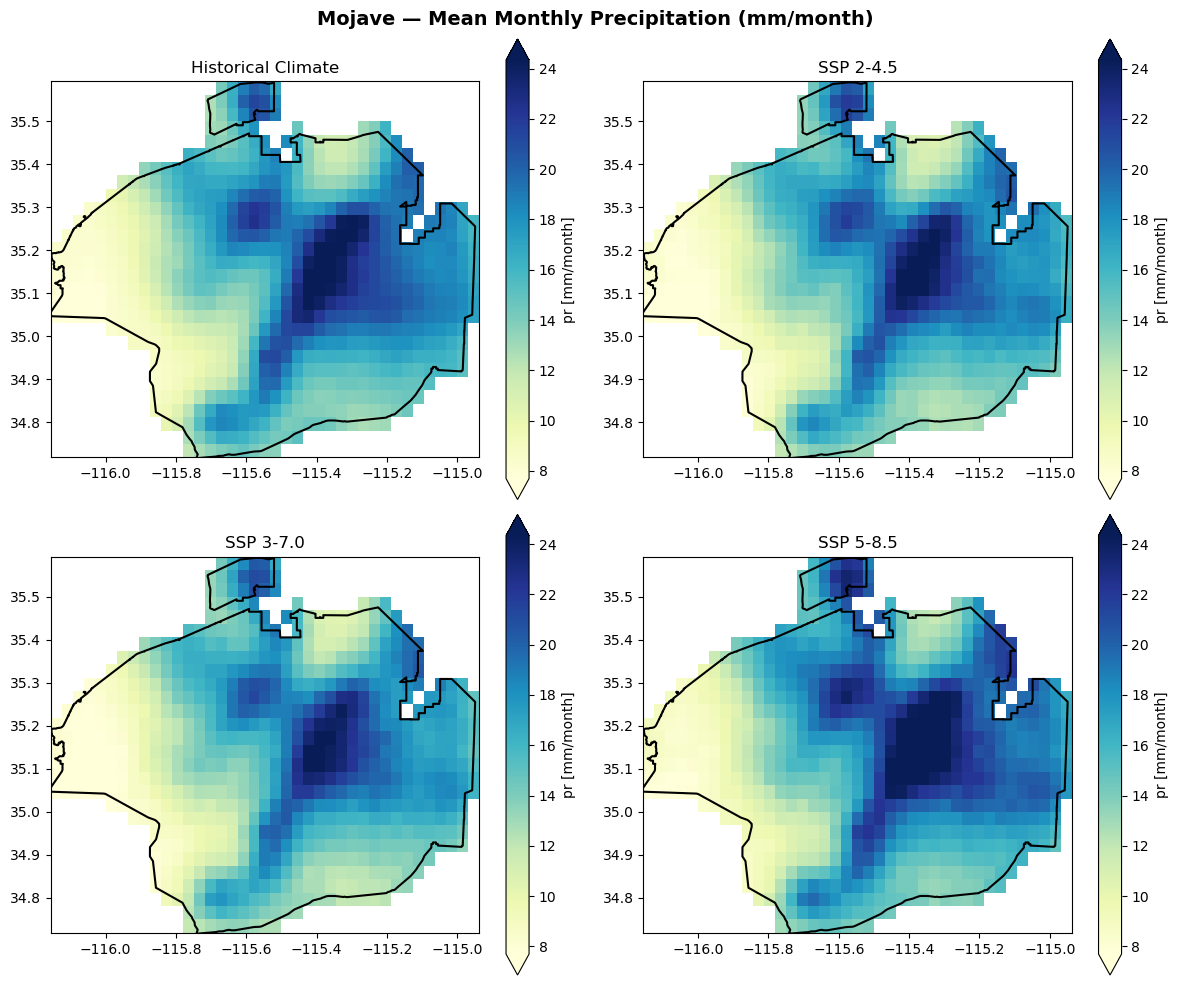

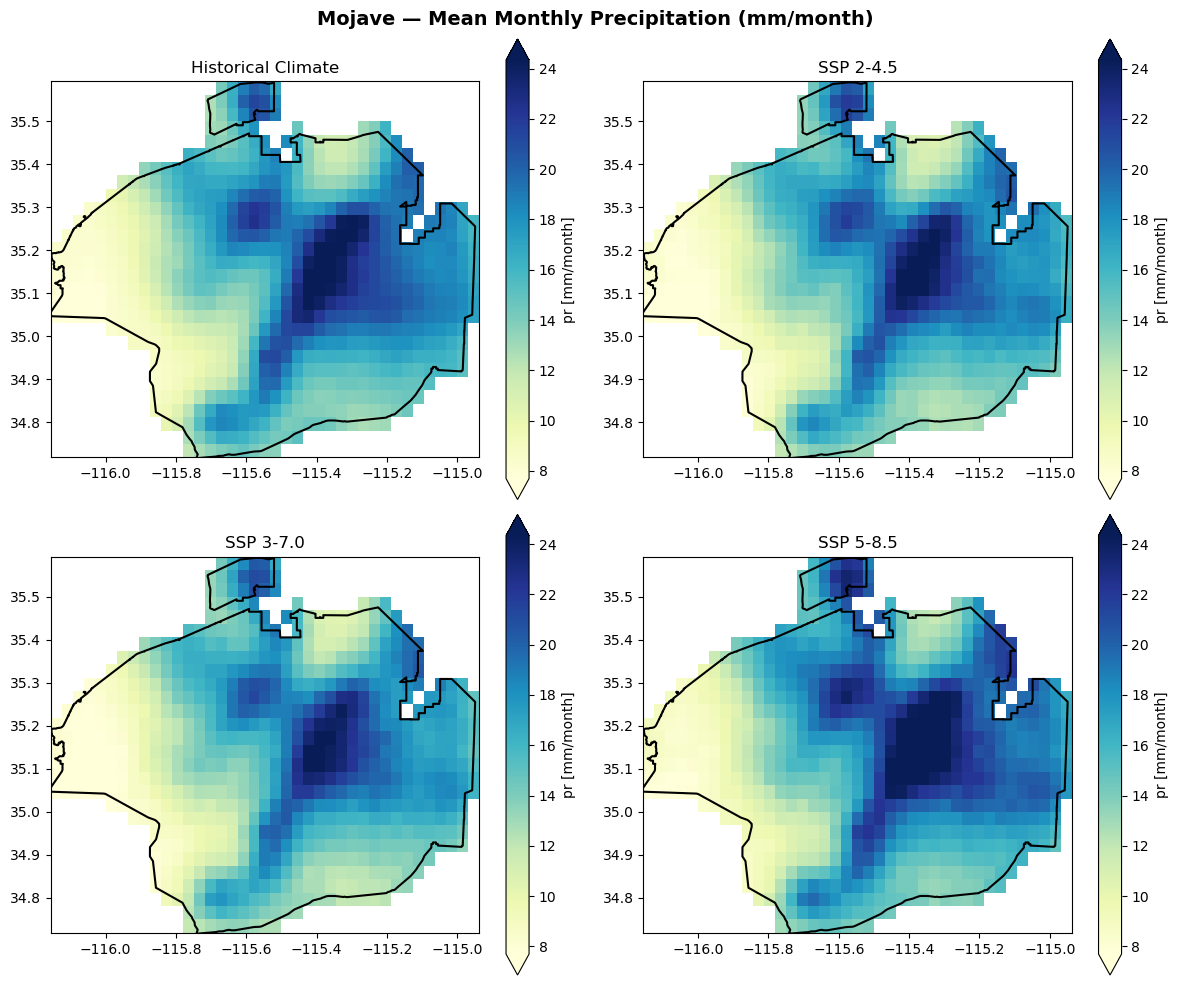

In [9]:
plot_spatial_comparison(
    mj_precip,
    boundary=mj,
    title="Mojave — Mean Monthly Precipitation (mm/month)",
    cmap="YlGnBu",
)

### Precipitation Anomalies

In [10]:
baseline = mj_precip["Historical Climate"]

mj_precip_anomalies = {
    f"{scen} minus Historical": da - baseline
    for scen, da in mj_precip.items()
    if scen != "Historical Climate"
}

for scen, da in mj_precip_anomalies.items():
    vals = da.values[~__import__('numpy').isnan(da.values)]
    print(f"{scen}: {vals.min():+.2f} to {vals.max():+.2f} mm/month")

SSP 2-4.5 minus Historical: -1.98 to +1.24 mm/month
SSP 3-7.0 minus Historical: -2.54 to +0.77 mm/month
SSP 5-8.5 minus Historical: -0.69 to +2.70 mm/month


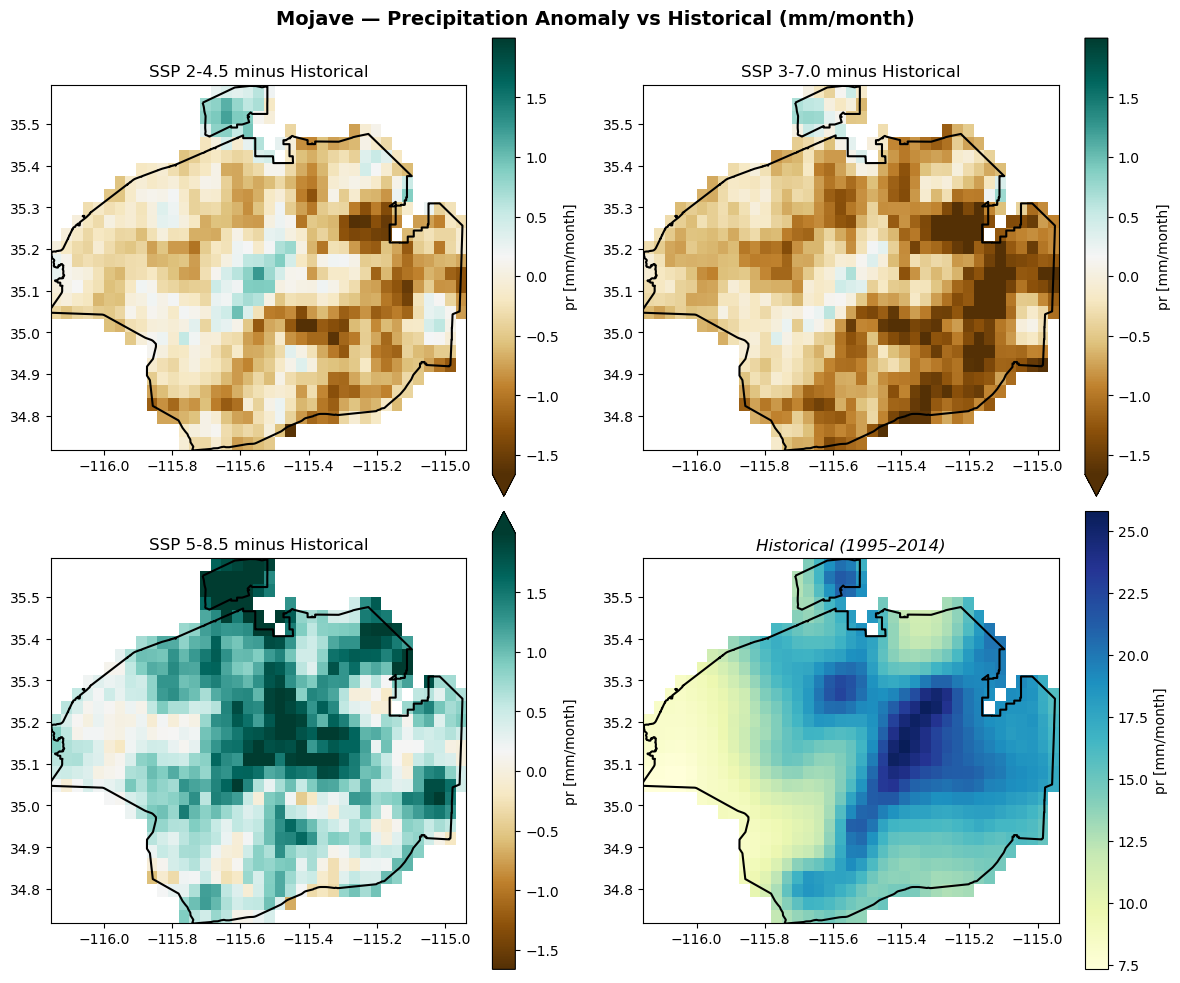

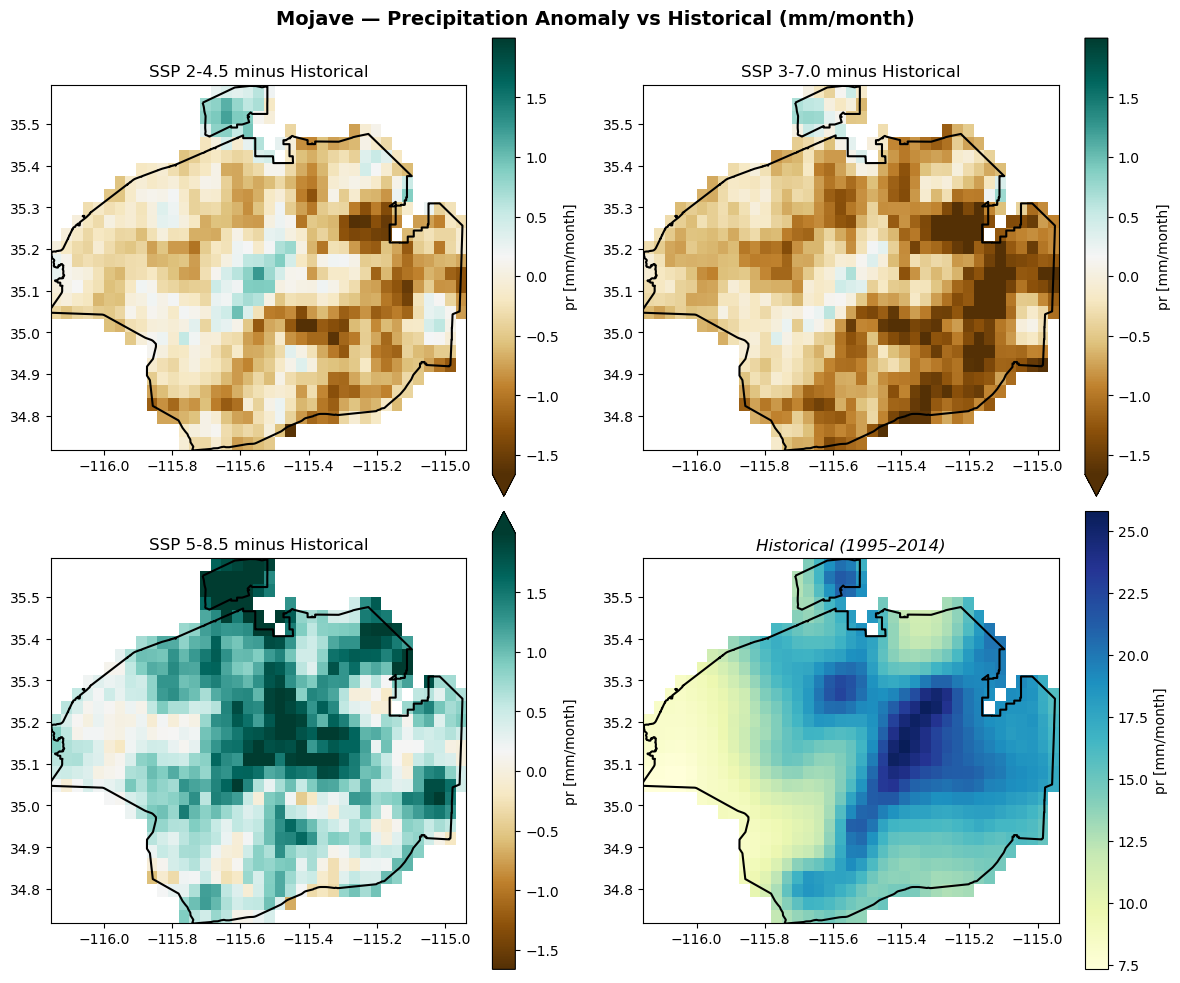

In [11]:
plot_spatial_comparison(
    mj_precip_anomalies,
    boundary=mj,
    title="Mojave — Precipitation Anomaly vs Historical (mm/month)",
    cmap="BrBG",
    reference_panel=("Historical (1995–2014)", mj_precip["Historical Climate"], "YlGnBu"),
)

## Shut Down

In [12]:
cluster.close()
print("Done.")

Done.
